# Setup

In [21]:
import torch

tensors_dir = "../data/tensors"

X_trainval = torch.load(f"{tensors_dir}/X_trainval.pt").float()
y_trainval = torch.load(f"{tensors_dir}/y_trainval.pt").long()
sample_weights = torch.load(f"{tensors_dir}/sample_weights.pt").float()

print(f"X_train: {X_trainval.shape}  {X_trainval.dtype}")
print(f"y_train: {y_trainval.shape}  {y_trainval.dtype}")
print(f"weights: {sample_weights.shape}")

X_train: torch.Size([796, 10])  torch.float32
y_train: torch.Size([796])  torch.int64
weights: torch.Size([796])


In [14]:
from src import MLP

INPUT_SIZE = X_trainval.shape[1]
NUM_CLASSES = 4

model = MLP(input_size = INPUT_SIZE, hidden_layers=[16, 64, 256, 512, 256, 64, 16],
            output_size = NUM_CLASSES, dropout_p = 0.3, activation='relu')
print(model)

dummy_output = model(torch.randn(8, INPUT_SIZE))
print(f"\noutput shape: {dummy_output.shape}")
print(f"\noutput values: {dummy_output}")

MLP(
  (input): Linear(in_features=10, out_features=16, bias=True)
  (hidden_layers): ModuleList(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): Linear(in_features=64, out_features=256, bias=True)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): Linear(in_features=256, out_features=64, bias=True)
    (5): Linear(in_features=64, out_features=16, bias=True)
  )
  (output): Linear(in_features=16, out_features=4, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (activation): ReLU()
)

output shape: torch.Size([8, 4])

output values: tensor([[-0.1434, -0.0787, -0.0734, -0.1486],
        [-0.1225, -0.0860, -0.0904, -0.1684],
        [-0.1599, -0.0584, -0.0806, -0.1512],
        [-0.1131, -0.1154, -0.0816, -0.1331],
        [-0.1084, -0.1443, -0.0931, -0.0985],
        [-0.1363, -0.0908, -0.0732, -0.1381],
        [-0.1434, -0.0927, -0.0671, -0.1254],
        [-0.1110, -0.1385, -0.

In [15]:
from src import build_fold_dataloaders

train_loader, val_loader = build_fold_dataloaders(X=X_trainval, y=y_trainval,
                                                  weights=sample_weights, fold_idx=0, batch_size=32, n_splits=5)

X_example_batch, y_example_batch = next(iter(train_loader))
print(f"Test loaders length: \nTrain: {len(train_loader)}   Val: {len(val_loader)}")
print(f"\nX batch info: \nshape: {X_example_batch.shape}   dtype: {X_example_batch.dtype}")
print(f"\nY batch info: \nshape: {y_example_batch.shape}   dtype: {y_example_batch.dtype}")

Test loaders length: 
Train: 20   Val: 5

X batch info: 
shape: torch.Size([32, 10])   dtype: torch.float32

Y batch info: 
shape: torch.Size([32])   dtype: torch.int64


In [16]:
from src import train_fold
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history = train_fold(model, train_loader, val_loader, optimizer, criterion, fold_idx=0,
          device=device, n_epochs=10,  write_model=True)
history

[Fold 0] Epoch   0/10 | train: 1.3869 | val: 1.3734 <- new best
[Fold 0] Epoch   1/10 | train: 1.3767 | val: 1.3469 <- new best
[Fold 0] Epoch   2/10 | train: 1.3121 | val: 1.2379 <- new best
[Fold 0] Epoch   3/10 | train: 1.2660 | val: 1.2247 <- new best
[Fold 0] Epoch   4/10 | train: 1.2292 | val: 1.2186 <- new best
[Fold 0] Epoch   5/10 | train: 1.2321 | val: 1.2138 <- new best
[Fold 0] Epoch   6/10 | train: 1.1913 | val: 1.2111 <- new best
[Fold 0] Epoch   7/10 | train: 1.2467 | val: 1.2220
[Fold 0] Epoch   8/10 | train: 1.2353 | val: 1.2299
[Fold 0] Epoch   9/10 | train: 1.1949 | val: 1.2207


{'train_losses': [1.3868812390093535,
  1.376673958586447,
  1.3120914960057481,
  1.2660039018535014,
  1.2292411732223798,
  1.2321313094792876,
  1.1912509892721597,
  1.246660590171814,
  1.2353428242341526,
  1.1948952839809395],
 'val_losses': [1.3733999729156494,
  1.3469111919403076,
  1.2379191637039184,
  1.2247210025787354,
  1.2186115026473998,
  1.213768768310547,
  1.211086630821228,
  1.2220140457153321,
  1.229931378364563,
  1.2206572771072388],
 'best_model_state': OrderedDict([('input.weight',
               tensor([[-0.0430, -0.0462, -0.0043, -0.2244,  0.1568,  0.0040, -0.3303,  0.2679,
                         0.0709, -0.0591],
                       [ 0.1432, -0.1874,  0.0577,  0.1718, -0.1428, -0.0402, -0.2777,  0.1180,
                        -0.2042,  0.0397],
                       [-0.0897,  0.2120, -0.1922, -0.1322, -0.0044,  0.0746, -0.0693,  0.0932,
                         0.2730, -0.2814],
                       [ 0.1757,  0.0766, -0.0275, -0.2385, -0.23

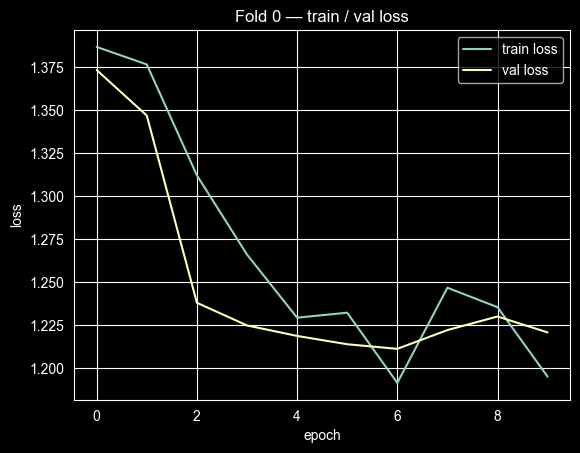

In [18]:
import matplotlib.pyplot as plt

epochs = range(len(history['train_losses']))

plt.plot(epochs, history['train_losses'], label='train loss')
plt.plot(epochs, history['val_losses'],   label='val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Fold 0 — train / val loss')
plt.legend()
plt.show()
